## Árboles de decisión

##### Introducción

En esta notebook se implementa el algoritmo **Decision Tree Regressor** para predecir el precio de venta de viviendas utilizando el dataset Ames Housing.

A diferencia de algoritmos como K-Nearest Neighbors o la regresión lineal, los árboles de decisión realizan predicciones dividiendo el conjunto de datos en regiones cada vez más homogéneas mediante reglas basadas en las variables explicativas. En cada división, el modelo selecciona la característica que mejor reduce la variabilidad del precio de venta, generando una estructura jerárquica de decisiones que resulta fácil de interpretar.

##### ❓ Preguntas a responder en esta notebook

- ¿Puede un árbol de decisión predecir el precio de venta de una vivienda?
- ¿Cuál es la profundidad óptima del árbol (`max_depth`)?
- ¿Cómo influye el tamaño mínimo de las hojas (`min_samples_leaf`) en el desempeño del modelo?
- ¿El modelo presenta signos de sobreajuste (overfitting)?
- ¿Cómo se compara su desempeño con KNN y la regresión lineal?

### Conjunto de datos

En esta notebook se utiliza la versión preprocesada del dataset **Ames Housing**, obtenida a partir del análisis exploratorio realizado previamente.

Durante esa etapa se seleccionaron las variables con mayor capacidad predictiva, se trataron los valores faltantes y se redujo el número de características para facilitar el entrenamiento y la comparación entre modelos.

El conjunto de datos final contiene **2930 observaciones** y **23 variables**, incluyendo la variable objetivo `SalePrice`.

In [30]:
# Librerias 
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score, accuracy_score,confusion_matrix,classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split,cross_val_score
import seaborn as sns
import plotly.express as px
import kagglehub
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from pathlib import Path
import os
from sklearn.model_selection import GridSearchCV
print ("librerias ok")

librerias ok


In [2]:
# Directorio actual
print(os.getcwd())

d:\Josefina\Proyectos\Datascience\Curso_ML\Modelos_ML\housing-price-analysis


In [4]:
#Dataset a utilizar descargado previamente de kaggle 
# https://www.kaggle.com/datasets/marcopale/housing?resource=download
housing = pd.read_csv("../data/AmesHousing_modificado.csv")

housing.head()

,Unnamed: 0,SalePrice,Overall Qual,Gr Liv Area,Total Bsmt SF,Garage Area,Year Built,Year Remod/Add,Full Bath,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Neighborhood,Kitchen Qual,Exter Qual,Bsmt Qual,Garage Finish,Foundation,House Style,Sale Condition
0,0,215000,6,1656,1080.0,528.0,1960,1960,1,112.0,...,210,62,NAmes,TA,TA,TA,Fin,CBlock,1Story,Normal
1,1,105000,5,896,882.0,730.0,1961,1961,1,0.0,...,140,0,NAmes,TA,TA,TA,Unf,CBlock,1Story,Normal
2,2,172000,6,1329,1329.0,312.0,1958,1958,1,108.0,...,393,36,NAmes,Gd,TA,TA,Unf,CBlock,1Story,Normal
3,3,244000,7,2110,2110.0,522.0,1968,1968,2,0.0,...,0,0,NAmes,Ex,Gd,TA,Fin,CBlock,1Story,Normal
4,4,189900,5,1629,928.0,482.0,1997,1998,2,0.0,...,212,34,Gilbert,TA,TA,Gd,Fin,PConc,2Story,Normal


In [5]:
#Eliminamos esa variable
housing = housing.drop(columns="Unnamed: 0")

In [6]:
housing.describe().T

,count,mean,std,min,25%,50%,75%,max
SalePrice,2930.0,180796.060068,79886.692357,12789.0,129500.00,160000.0,213500.00,755000.0
Overall Qual,2930.0,6.094881,1.411026,1.0,5.00,6.0,7.00,10.0
Gr Liv Area,2930.0,1499.690444,505.508887,334.0,1126.00,1442.0,1742.75,5642.0
Total Bsmt SF,2929.0,1051.614544,440.615067,0.0,793.00,990.0,1302.00,6110.0
Garage Area,2929.0,472.819734,215.046549,0.0,320.00,480.0,576.00,1488.0
Year Built,2930.0,1971.356314,30.245361,1872.0,1954.00,1973.0,2001.00,2010.0
Year Remod/Add,2930.0,1984.266553,20.860286,1950.0,1965.00,1993.0,2004.00,2010.0
Full Bath,2930.0,1.566553,0.552941,0.0,1.00,2.0,2.00,4.0
Mas Vnr Area,2907.0,101.896801,179.112611,0.0,0.00,0.0,164.00,1600.0
Fireplaces,2930.0,0.599317,0.647921,0.0,0.00,1.0,1.00,4.0


In [20]:
housing.shape

(2930, 22)

In [21]:
housing.columns

Index(['SalePrice', 'Overall Qual', 'Gr Liv Area', 'Total Bsmt SF',
       'Garage Area', 'Year Built', 'Year Remod/Add', 'Full Bath',
       'Mas Vnr Area', 'Fireplaces', 'Lot Area', 'Lot Frontage',
       'Wood Deck SF', 'Open Porch SF', 'Neighborhood', 'Kitchen Qual',
       'Exter Qual', 'Bsmt Qual', 'Garage Finish', 'Foundation', 'House Style',
       'Sale Condition'],
      dtype='str')

In [7]:
# Variables numéricas
variables_numericas = [
    "Overall Qual",
    "Gr Liv Area",
    "Total Bsmt SF",
    "Garage Area",
    "Year Built",
    "Year Remod/Add",
    "Full Bath",
    "Mas Vnr Area",
    "Fireplaces",
    "Lot Area",
    "Lot Frontage",
    "Wood Deck SF",
    "Open Porch SF"
]

# Variables categóricas
variables_categoricas = [
    "Neighborhood",
    "Kitchen Qual",
    "Exter Qual",
    "Bsmt Qual",
    "Garage Finish",
    "Foundation",
    "House Style",
    "Sale Condition"
]

# Variables predictoras
X = housing[variables_numericas + variables_categoricas]

# Variable objetivo
y = housing["SalePrice"]

In [ ]:
# numericas = X.select_dtypes(include="number").columns
# categoricas = X.select_dtypes(exclude="number").columns

In [8]:
X = pd.get_dummies(X, drop_first=True)

In [9]:
# Creamos dataset de entrenamiento y testeo
x_train, x_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state = 42)

In [10]:
# Se crea y entrena el arbol de decision sin restriccion hasta que encuentre la pureza
# 01. Se setea el modelo
arbol_completo = DecisionTreeRegressor(random_state = 42)
# 02. Se entrena
arbol_completo.fit (x_train, y_train)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

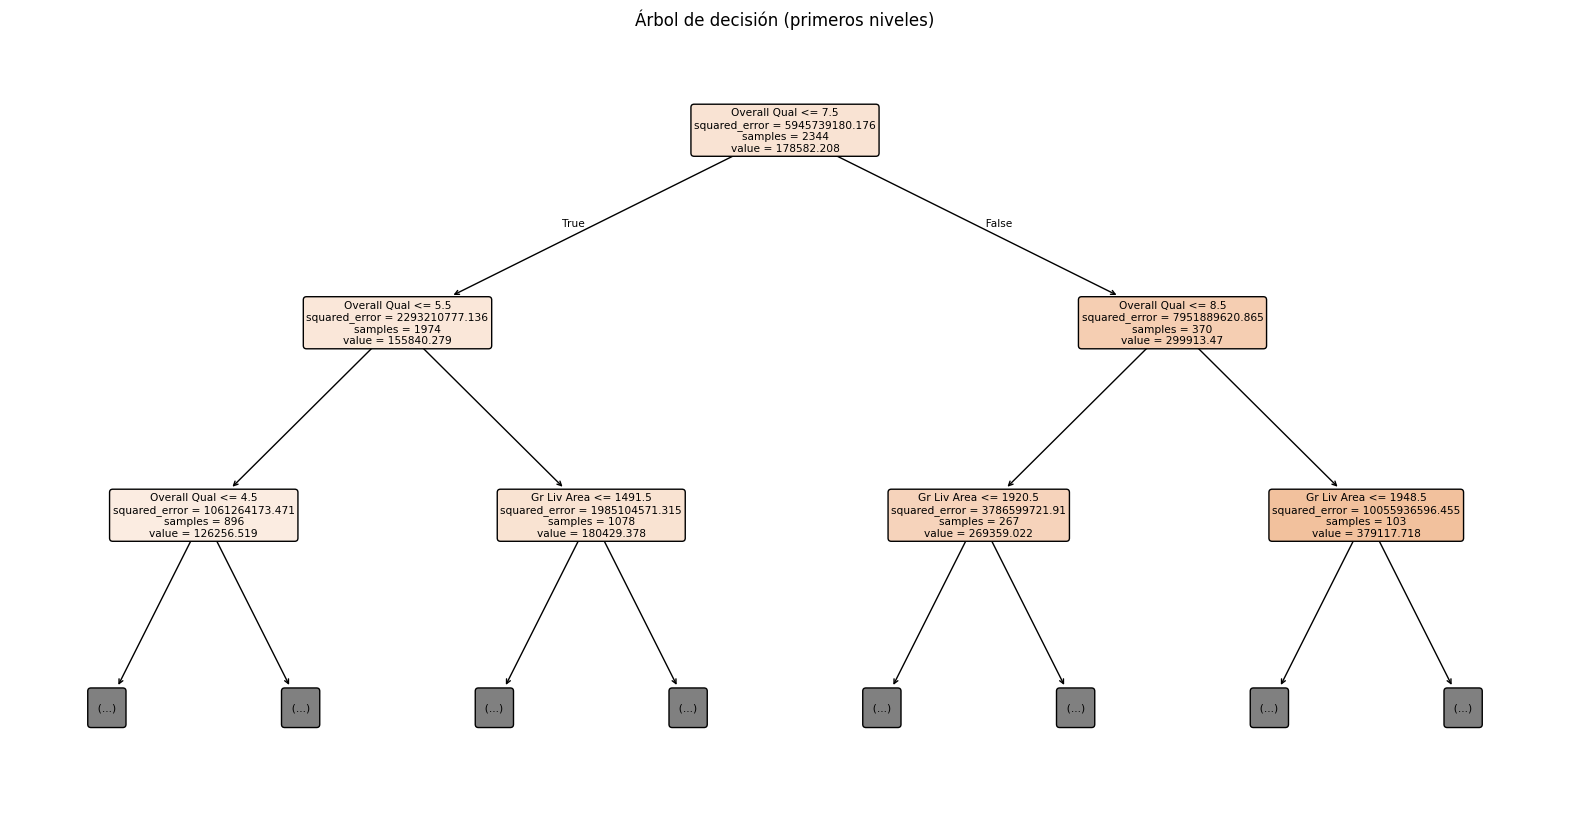

In [13]:
# Visualizamos el arbol completo

plt.figure(figsize=(20,10))

plot_tree( arbol_completo, feature_names=x_train.columns, filled=True,  rounded=True, max_depth=2)  # Para visualizar solo los primeros niveles


plt.title("Árbol de decisión (primeros niveles)")
plt.show()

In [ ]:
# Evaluacion del desempeño
# 01. Predicciones del arbol sobre el conjunto de prueba
y_pred_completo = arbol_completo.predict (x_test)

# 02. Metricas
# \ ALT 92
mae = mean_absolute_error(y_test, y_pred_completo)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_completo))
r2 = r2_score(y_test, y_pred_completo)

print("Desempeño del árbol de decisión\n")

print(f"MAE : {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R²  : {r2:.4f}")



Desempeño del árbol de decisión

MAE : 26,508.83
RMSE: 44,587.74
R²  : 0.7520


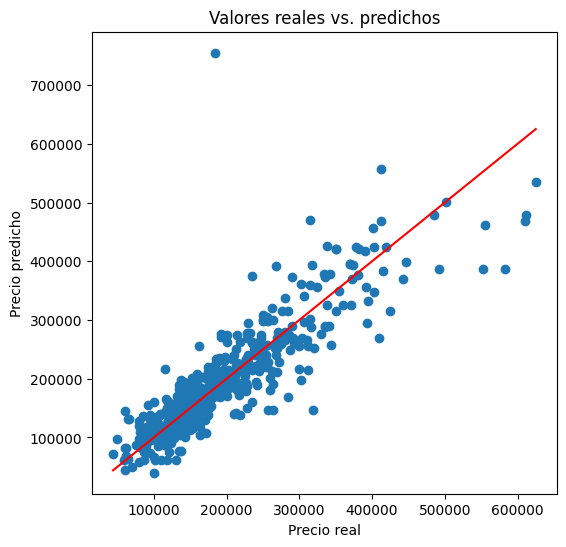

In [ ]:
# Plot de Valores reales vs. predichos
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_completo)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")

plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Valores reales vs. predichos")

plt.show()

In [15]:
# Vamos a calcular las metricas del entrenamiento, porque estos arboles suelen hacer overfitting
y_pred_train_completo = arbol_completo.predict(x_train)

print("Entrenamiento")
print(f"R²: {r2_score(y_train, y_pred_train_completo):.4f}")

print("\nPrueba")
print(f"R²: {r2_score(y_test, y_pred_completo):.4f}")

Entrenamiento
R²: 1.0000

Prueba
R²: 0.7520


Este arbol obtuvo un R² = **1.00** sobre el conjunto de entrenamiento, lo que indica un ajuste perfecto a los datos utilizados para el aprendizaje.

Sin embargo, al evaluar el modelo sobre el conjunto de prueba, el R² disminuye a **0.752**, evidenciando una pérdida importante de capacidad de generalización. 

Esta diferencia entre ambos conjuntos sugiere que el árbol presenta **sobreajuste (overfitting)**, es decir, aprendió en exceso las particularidades del conjunto de entrenamiento en lugar de capturar patrones generales.

En las siguientes secciones se ajustarán hiperparámetros como `max_depth` y `min_samples_leaf` con el objetivo de controlar la complejidad del árbol y mejorar su capacidad predictiva sobre datos no observados.

Ahora quiero mejorar el modelo

Algunas ideas:
- Ponerle mas peso a una variable que a otra, prestarle mas atencion.
- Ingeniería de caracaterísticas (features)
- Hiperpáramentros

#### Ajuste del hiperparámetro `max_depth`

La profundidad máxima controla la complejidad del árbol de decisión.

- Árboles poco profundos pueden no capturar correctamente la relación entre las variables (underfitting).
- Árboles muy profundos pueden memorizar el conjunto de entrenamiento y perder capacidad de generalización (overfitting).

En este apartado se evalúa cómo cambia el desempeño del modelo para diferentes profundidades.

In [21]:
# Probamos varias parametros de max_depth
resultados_depth = []

profundidades = range(2,21)

for depth in profundidades:
    modelo = DecisionTreeRegressor( max_depth = depth, random_state = 42)

    modelo.fit(x_train, y_train)
    pred_train = modelo.predict(x_train)
    pred_test = modelo.predict(x_test)

    #Resultados del despempeño
    resultados_depth.append({
        "max_depth": depth,
        "R2_train": r2_score(y_train, pred_train),
        "R2_test": r2_score(y_test, pred_test),

        "mae_test" : mean_absolute_error(y_test, pred_test),
        "rmse_test" : np.sqrt(mean_squared_error(y_test, pred_test)),

        "mae_train" : mean_absolute_error(y_train, pred_train),
        "rmse_train" : np.sqrt(mean_squared_error(y_train, pred_train))
    })
resultados_depth = pd.DataFrame(resultados_depth)
resultados_depth

,max_depth,R2_train,R2_test,mae_test,rmse_test,mae_train,rmse_train
0,2,0.631363,0.675513,36096.528335,51005.819064,33733.006421,46816.845143
1,3,0.725373,0.771560,30330.415368,42796.316017,28829.100425,40408.657992
2,4,0.789769,0.815024,26746.725132,38510.470590,24762.966855,35355.012849
3,5,0.844866,0.848468,24629.009364,34855.676911,21745.168035,30370.828504
4,6,0.889031,0.859813,23167.940220,33525.480306,18482.375020,25686.448544
5,7,0.917283,0.840419,23515.198134,35769.415523,16104.099010,22176.937941
6,8,0.940702,0.843647,23186.513036,35405.795686,13594.100347,18776.793603
7,9,0.959514,0.844173,23403.087630,35346.182753,11085.098961,15515.187107
8,10,0.973039,0.837540,24055.568635,36090.548178,8511.683909,12661.141412
9,11,0.982398,0.762158,25760.600255,43668.149133,6331.238051,10230.108155


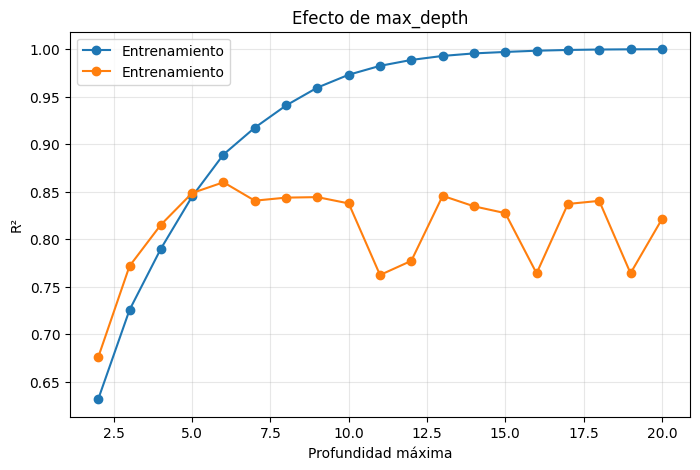

In [19]:
#Grafico para entenderlo mejor a todas las meticas

plt.figure(figsize=(8,5))
plt.plot(resultados_depth["max_depth"], resultados_depth["R2_train"], marker="o", label="Entrenamiento")
plt.plot(resultados_depth["max_depth"], resultados_depth["R2_test"], marker="o", label="Entrenamiento")

plt.xlabel("Profundidad máxima")
plt.ylabel("R²")
plt.title("Efecto de max_depth")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

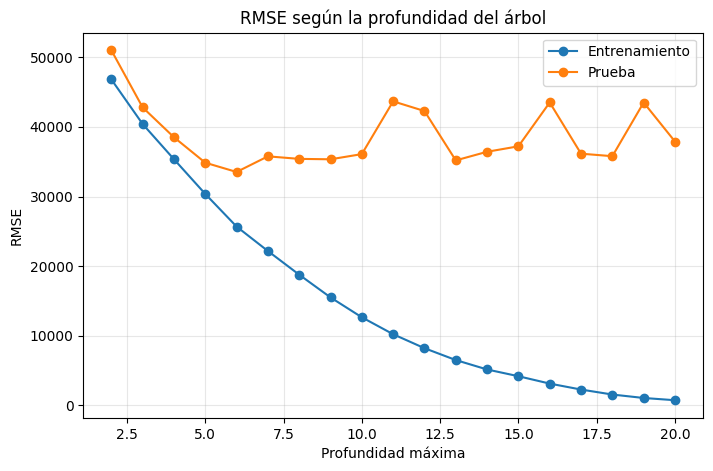

In [23]:
# Mismo plot pero con RMSE
plt.figure(figsize=(8,5))

plt.plot(resultados_depth["max_depth"], resultados_depth["rmse_train"], marker="o", label="Entrenamiento")
plt.plot(resultados_depth["max_depth"], resultados_depth["rmse_test"], marker="o", label="Prueba")

plt.xlabel("Profundidad máxima")
plt.ylabel("RMSE")
plt.title("RMSE según la profundidad del árbol")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

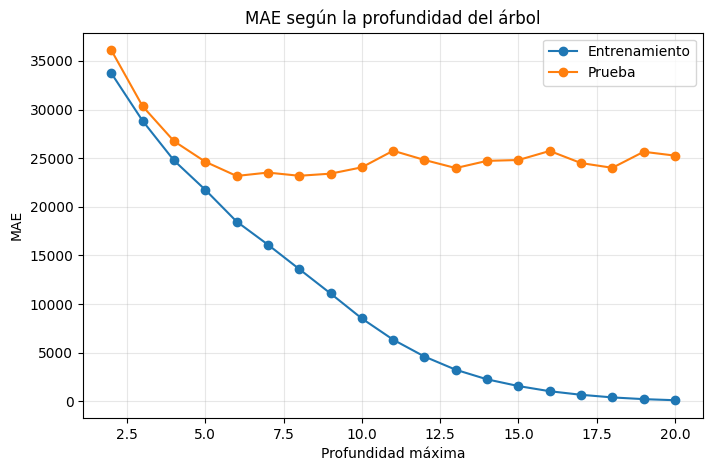

In [24]:
# Mismo plot pero con mae_train
plt.figure(figsize=(8,5))

plt.plot(resultados_depth["max_depth"], resultados_depth["mae_train"], marker="o", label="Entrenamiento")
plt.plot(resultados_depth["max_depth"], resultados_depth["mae_test"], marker="o", label="Prueba")

plt.xlabel("Profundidad máxima")
plt.ylabel("MAE")
plt.title("MAE según la profundidad del árbol")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

##### Resumen
Al incrementar *max_depth*, el árbol aumenta su capacidad para ajustar los datos de entrenamiento, alcanzando un R² cercano a 1 para profundidades elevadas. Sin embargo, el desempeño sobre el conjunto de prueba mejora únicamente hasta max_depth = 6, donde se obtiene el mayor R² (0.86). A partir de ese valor, el modelo continúa ajustándose al conjunto de entrenamiento, pero pierde capacidad de generalización, evidenciando un fenómeno de sobreajuste.

En cuanto a MAE disminuye continuamente a medida que aumenta la profundidad del árbol. Esto es esperable: un árbol más complejo ajusta cada vez mejor los datos de entrenamiento y reduce el error promedio hasta casi cero. Donde alrededor de max_depth = 6 alcanza su mínimo.

El RMSE es aún más interesante porque penaliza mucho los errores grandes. Disminuye muchísimo. Eso significa que el árbol prácticamente elimina los errores grandes sobre el conjunto de entrenamiento. Nuevamente, el menor RMSE se obtiene con max_depth = 6 y después vuelve a aumentar. Eso indica que empiezan a aparecer errores grandes sobre datos nuevos.

el RMSE empeora más que el MAE cuando el árbol empieza a sobreajustarse.

##### Otra prueba: Optimizar min_samples_leaf

In [27]:
samples_leaf = [1, 2, 5, 10, 15, 20, 30, 50]
resultados_samples_leaf = []


for leaf in samples_leaf:
    modelo = DecisionTreeRegressor( max_depth = 6, random_state = 42, min_samples_leaf= leaf)

    modelo.fit(x_train, y_train)
    pred_train = modelo.predict(x_train)
    pred_test = modelo.predict(x_test)

    #Resultados del despempeño
    resultados_samples_leaf.append({
        "min_samples_leaf": leaf,
        "R2_train": r2_score(y_train, pred_train),
        "R2_test": r2_score(y_test, pred_test),

        "mae_test" : mean_absolute_error(y_test, pred_test),
        "rmse_test" : np.sqrt(mean_squared_error(y_test, pred_test)),

        "mae_train" : mean_absolute_error(y_train, pred_train),
        "rmse_train" : np.sqrt(mean_squared_error(y_train, pred_train))
    })
resultados_samples_leaf = pd.DataFrame(resultados_samples_leaf)
resultados_samples_leaf

,min_samples_leaf,R2_train,R2_test,mae_test,rmse_test,mae_train,rmse_train
0,1,0.889031,0.859813,23167.940220,33525.480306,18482.375020,25686.448544
1,2,0.886636,0.794129,23964.272650,40627.378336,18551.445214,25962.180870
2,5,0.873310,0.839876,23420.951047,35830.197823,19096.311944,27445.638145
3,10,0.864692,0.828986,23608.644730,37028.531261,19350.974105,28363.795929
4,15,0.852163,0.837831,23141.606737,36058.234489,19886.913812,29647.919445
5,20,0.842667,0.847810,23268.169112,34931.227724,20076.622317,30585.330823
6,30,0.826651,0.841954,23483.892221,35596.978846,20919.863002,32104.335878
7,50,0.812224,0.844612,23186.179334,35296.381276,21928.006960,33413.562311


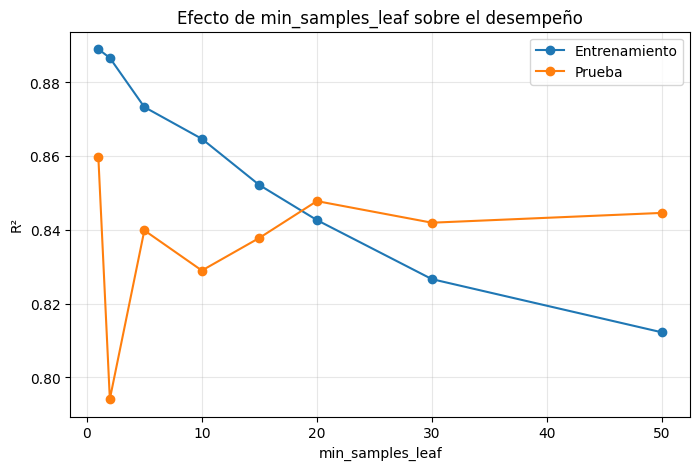

In [ ]:
# Plot de metricas
plt.figure(figsize=(8,5))

plt.plot(resultados_samples_leaf["min_samples_leaf"], resultados_samples_leaf["R2_train"], marker="o", label="Entrenamiento")
plt.plot(resultados_samples_leaf["min_samples_leaf"], resultados_samples_leaf["R2_test"], marker="o", label="Prueba")
plt.xlabel("min_samples_leaf")
plt.ylabel("R²")
plt.title("Efecto de min_samples_leaf sobre el desempeño")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

#### Resumen
A medida que aumenta min_samples_leaf, el árbol se vuelve más simple, pero no mejora, sino que se mantiene

Pero al aumentar min_samples_leaf reduce la complejidad del árbol, pero en este caso no logra mejorar la generalización.

In [31]:
# Busqueda de los mejores hiperparametos
arbol = DecisionTreeRegressor(random_state=42)
param_grid = {
    "max_depth": [3, 4, 5, 6, 7, 8, 10],
    "min_samples_leaf": [1, 2, 5, 10, 15, 20, 30]
}

# n_jobs=-1 ==> utiliza todos los núcleos disponibles
grid_search = GridSearchCV(estimator=arbol, param_grid=param_grid, cv=5, scoring="r2", n_jobs=-1)
#Entrenamos
grid_search.fit(x_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 

In [32]:
#Mejor hiperparametros encontrados
print("Mejores hiperparámetros:")
print(grid_search.best_params_)

print(f"Mejor R² CV: {grid_search.best_score_:.4f}")



Mejores hiperparámetros:
{'max_depth': 10, 'min_samples_leaf': 15}
Mejor R² CV: 0.8000


In [33]:
# Ahora usamos el mejor árbol encontrado
mejor_arbol = grid_search.best_estimator_

#Y se gneran las predicciones con el set de test
y_pred_grid = mejor_arbol.predict(x_test)

#Metricas
print("Desempeño en test")

print( f"R²: {r2_score(y_test,y_pred_grid):.4f}")

print( f"MAE: {mean_absolute_error(y_test,y_pred_grid):,.2f}")

print(f"RMSE: {np.sqrt(mean_squared_error(y_test,y_pred_grid)):,.2f}")

Desempeño en test
R²: 0.8459
MAE: 22,098.07
RMSE: 35,152.84


#### Resumen
La optimización mediante GridSearchCV permitió encontrar una combinación de hiperparámetros con un desempeño competitivo. Si bien el mejor R² obtenido mediante exploración manual (max_depth=6) fue ligeramente superior, la búsqueda automática encontró un modelo con menor MAE, mostrando un comportamiento más equilibrado en términos de error promedio.

#### 3. Importancia de variables

        Variable  Importancia
0   Overall Qual     0.745485
1    Gr Liv Area     0.116176
2  Total Bsmt SF     0.068792
3    Garage Area     0.017294
4     Year Built     0.005358


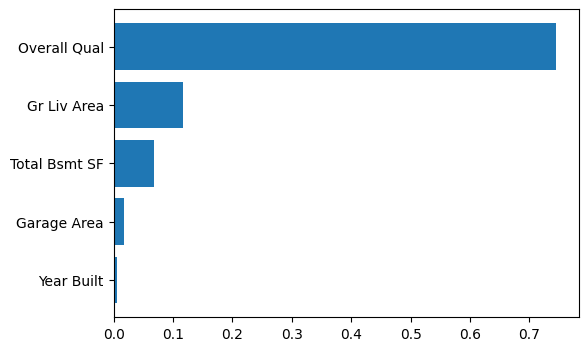

In [42]:
# 3. Importancia de variables

importancias = pd.DataFrame({
    "Variable": x_train.columns,
    "Importancia": mejor_arbol.feature_importances_
})

importancias.sort_values("Importancia", ascending=False) 

# Solo las primeras 5
top_5 = importancias[0:5]
print(top_5)


# Plot
plt.figure(figsize=(6,4))
plt.barh(top_5["Variable"], top_5["Importancia"])
plt.gca().invert_yaxis()
plt.show()

#### Importancia de variables

La importancia de variables permite identificar qué características fueron más utilizadas por el árbol de decisión para realizar las particiones y generar las predicciones.

Las variables con mayor contribución al modelo fueron:

- **Overall Qual**, que concentra aproximadamente el 74% de la importancia total, indicando que la calidad general de la vivienda es el principal factor utilizado por el modelo.
- **Gr Liv Area** y **Total Bsmt SF**, asociadas al tamaño de la propiedad, representan los siguientes factores más relevantes.
- **Garage Area** y **Year Built** presentan una contribución menor dentro del modelo.

Estos resultados son consistentes con el problema analizado, ya que tanto la calidad constructiva como la superficie disponible son factores determinantes en la valoración de una vivienda.

## Conclusiones generales de la notebook

En esta notebook se implementó un modelo de Árbol de Decisión para predecir el precio de venta de viviendas utilizando el dataset Ames Housing.

El modelo inicial sin restricciones logró un ajuste perfecto sobre los datos de entrenamiento (R² = 1.00), pero presentó una disminución en su desempeño sobre el conjunto de prueba, evidenciando un problema de sobreajuste. Esto permitió analizar la importancia de controlar la complejidad del árbol mediante el ajuste de hiperparámetros.

A través del análisis de `max_depth` se observó que aumentar la profundidad del árbol mejora el ajuste sobre los datos de entrenamiento, pero no necesariamente mejora la capacidad de generalización. El mejor equilibrio se obtuvo utilizando una profundidad intermedia, evitando que el modelo memorice las observaciones del conjunto de entrenamiento.

Posteriormente, se evaluó el efecto de `min_samples_leaf` y se realizó una búsqueda automática de hiperparámetros mediante `GridSearchCV` utilizando validación cruzada. Esta optimización permitió seleccionar una configuración del árbol con un desempeño adecuado sobre datos no observados.

El modelo final obtuvo un desempeño de:

- R²: 0.8459
- MAE: 22.098
- RMSE: 35.153

Estos resultados indican que el modelo logra explicar una proporción significativa de la variabilidad del precio de las viviendas, con un error promedio cercano a 22 mil unidades monetarias.

Finalmente, el análisis de importancia de variables mostró que **Overall Qual** fue la característica más influyente en las predicciones, seguida por variables relacionadas con el tamaño de la vivienda como **Gr Liv Area** y **Total Bsmt SF**. Estos resultados son coherentes con el problema analizado, ya que la calidad constructiva y la superficie representan factores determinantes en la valoración inmobiliaria.
